<a href="https://colab.research.google.com/github/iras-mpark/MLA1020/blob/main/week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np

# Exmaple of Predictor

### Binary Classification (기계학습 X, Just 예시)



In [3]:
def simple_binary_classifier(x: np.ndarray) -> int:
  logit = x[0] - x[1] - 1
  if logit > 0:
    predicted_y = 1
  else:
    predicted_y = -1
  return predicted_y

In [4]:
x_a = np.array([1, 2])
predicted_y_a = simple_binary_classifier(x_a)
print("x_a=", x_a, "-> predicted_y_a=", predicted_y_a)

x_b = np.array([2, 0])
predicted_y_b = simple_binary_classifier(x_b)
print("x_b=", x_b, "-> predicted_y_b=", predicted_y_b)


x_a= [1 2] -> predicted_y_a= -1
x_b= [2 0] -> predicted_y_b= 1


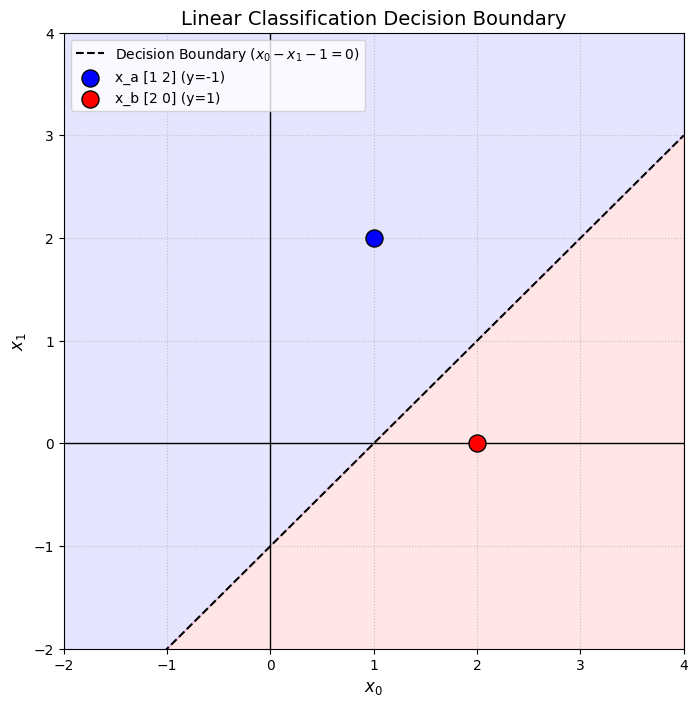

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

# 1. 결정 경계선 그리기 (x1 = x0 - 1)
x0_vals = np.linspace(-3, 4, 100)
x1_vals = x0_vals - 1
plt.plot(x0_vals, x1_vals, 'k--', label='Decision Boundary ($x_0 - x_1 - 1 = 0$)')

# 2. 분류 영역 색칠하기
# logit < 0 인 영역 (Predicted: -1, 파란색 영역)
plt.fill_between(x0_vals, x1_vals, 4, color='blue', alpha=0.1)
# logit > 0 인 영역 (Predicted: 1, 빨간색 영역)
plt.fill_between(x0_vals, -4, x1_vals, color='red', alpha=0.1)

# 3. 데이터 포인트 그리기
# x_a: 파란색 원, x_b: 빨간색 원
plt.scatter(x_a[0], x_a[1], color='blue', s=150, edgecolors='black', zorder=5, label=f'x_a {x_a} (y={predicted_y_a})')
plt.scatter(x_b[0], x_b[1], color='red', s=150, edgecolors='black', zorder=5, label=f'x_b {x_b} (y={predicted_y_b})')

# 4. 축 설정 및 꾸미기
plt.axhline(0, color='black', linewidth=1) # x축
plt.axvline(0, color='black', linewidth=1) # y축
plt.xlim(-2, 4)
plt.ylim(-2, 4)
plt.xlabel('$x_0$', fontsize=12)
plt.ylabel('$x_1$', fontsize=12)
plt.title('Linear Classification Decision Boundary', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper left')

# 그래프 출력
plt.show()

### How to set Line(= 기계학습 O)

In [6]:
class Example:
  x: np.ndarray
  target_y: float

  def __init__(self, x: np.ndarray, target_y: float):
    self.x = x
    self.target_y = target_y

def get_training_data():
  return [
    Example(x=np.array([1, 2]), target_y=-1),
    Example(x=np.array([2, 0]), target_y=1),
    Example(x=np.array([0, 0]), target_y=-1),
  ]

def example_to_point(example: Example) -> dict:
  return {"x0": example.x[0], "x1": example.x[1], "color": "red" if example.target_y == 1 else "blue"}

training_data = get_training_data()

data = [example_to_point(example) for example in training_data]
data

[{'x0': np.int64(1), 'x1': np.int64(2), 'color': 'blue'},
 {'x0': np.int64(2), 'x1': np.int64(0), 'color': 'red'},
 {'x0': np.int64(0), 'x1': np.int64(0), 'color': 'blue'}]

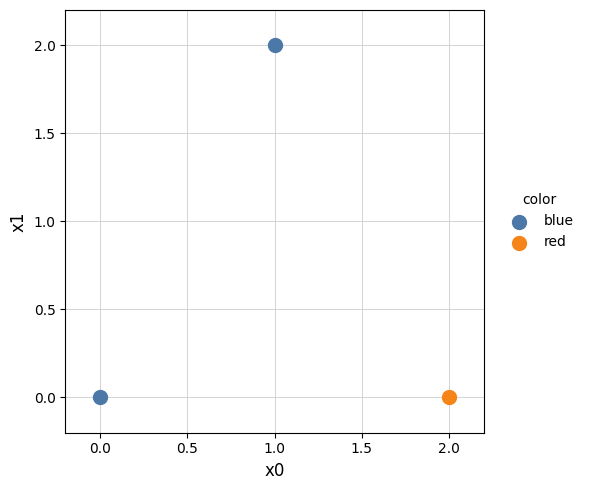

In [7]:
plt.figure(figsize=(6, 5))

# 범례(Legend)에 색상을 각각 표시하기 위해 데이터를 파란색/빨간색으로 분리
blue_points = [d for d in data if d['color'] == 'blue']
red_points = [d for d in data if d['color'] == 'red']

# 파란색 데이터 포인트 그리기
plt.scatter([d['x0'] for d in blue_points], [d['x1'] for d in blue_points],
            color='#4c78a8', s=100, label='blue', zorder=3)

# 빨간색 데이터 포인트 그리기
plt.scatter([d['x0'] for d in red_points], [d['x1'] for d in red_points],
            color='#f58518', s=100, label='red', zorder=3)

# 축 이름 및 범위 설정 (0.0 ~ 2.0 범위가 잘 보이도록 여백 추가)
plt.xlabel('x0', fontsize=12)
plt.ylabel('x1', fontsize=12)
plt.xlim(-0.2, 2.2)
plt.ylim(-0.2, 2.2)

# 그리드 설정
plt.grid(True, color='lightgray', linestyle='-', linewidth=0.7, zorder=0)

# 범례 설정
plt.legend(title='color', loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

# 레이아웃 조정 및 출력
plt.tight_layout()
plt.show()

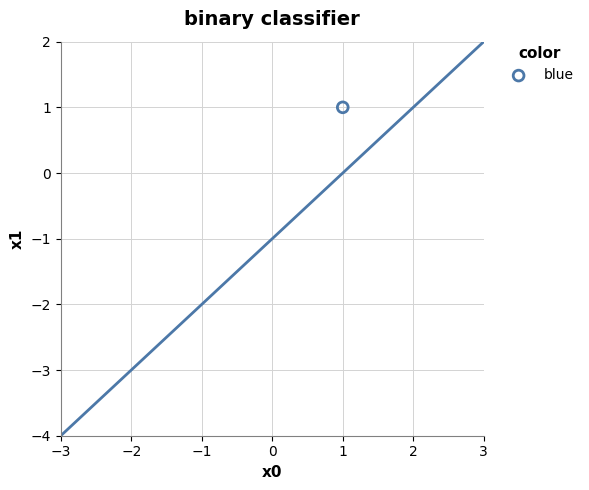

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

@dataclass
class Parameters:
    weight: np.ndarray
    bias: float

def binary_classifier(params: Parameters, x: np.ndarray) -> int:
    logit = params.weight @ x + params.bias
    if logit > 0:
        predicted_y = 1
    else:
        predicted_y = -1
    return predicted_y

# 주어진 데이터
params = Parameters(weight=np.array([1, -1]), bias=-1)
x = np.array([1, 1])
predicted_y = binary_classifier(params, x)

# 예측값에 따른 색상 결정 (1: red, -1: blue)
color_name = "red" if predicted_y == 1 else "blue"
plot_color = '#f58518' if color_name == "red" else '#4c78a8'

# --- 시각화 코드 ---
fig, ax = plt.subplots(figsize=(6, 5))

# 1. 결정 경계(Decision Boundary) 계산 및 그리기
# 수식: w0*x0 + w1*x1 + b = 0  =>  x1 = (-w0*x0 - b) / w1
x0_vals = np.array([-3, 3])
x1_vals = (-params.weight[0] * x0_vals - params.bias) / params.weight[1]
ax.plot(x0_vals, x1_vals, color='#4c78a8', linewidth=2, zorder=2)

# 2. 데이터 포인트 그리기 (속이 빈 동그라미)
ax.scatter([x[0]], [x[1]], facecolors='none', edgecolors=plot_color,
           linewidth=2, s=60, label=color_name, zorder=3)

# 3. 그래프 스타일 및 축 설정
ax.set_title("binary classifier", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("x0", fontsize=11, fontweight='bold')
ax.set_ylabel("x1", fontsize=11, fontweight='bold')

# 첨부 이미지와 동일한 축 범위
ax.set_xlim(-3, 3)
ax.set_ylim(-4, 2)

# 그리드 설정
ax.grid(True, color='lightgray', linestyle='-', linewidth=0.7, zorder=0)

# 불필요한 테두리 숨기기 및 색상 변경
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('gray')
ax.spines['left'].set_color('gray')

# 범례 설정 (그래프 바깥쪽 우측 상단)
ax.legend(title='color', title_fontproperties={'weight':'bold', 'size':11},
          loc='upper left', bbox_to_anchor=(1.02, 1.02), frameon=False)

plt.tight_layout()
plt.show()

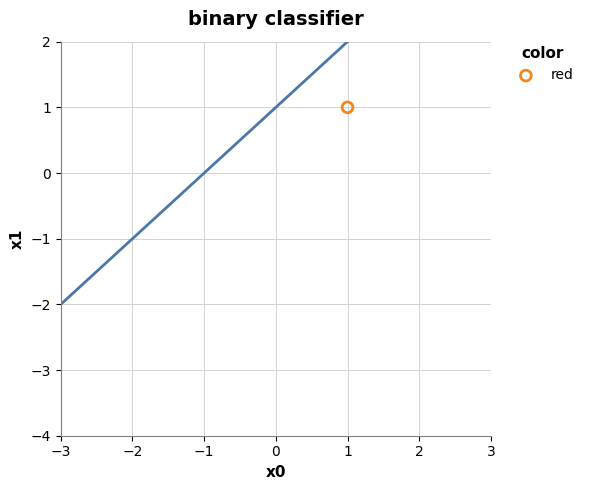

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

@dataclass
class Parameters:
    weight: np.ndarray
    bias: float

def binary_classifier(params: Parameters, x: np.ndarray) -> int:
    logit = params.weight @ x + params.bias
    if logit > 0:
        predicted_y = 1
    else:
        predicted_y = -1
    return predicted_y

# 주어진 데이터
params = Parameters(weight=np.array([1, -1]), bias=+1)
x = np.array([1, 1])
predicted_y = binary_classifier(params, x)

# 예측값에 따른 색상 결정 (1: red, -1: blue)
color_name = "red" if predicted_y == 1 else "blue"
plot_color = '#f58518' if color_name == "red" else '#4c78a8'

# --- 시각화 코드 ---
fig, ax = plt.subplots(figsize=(6, 5))

# 1. 결정 경계(Decision Boundary) 계산 및 그리기
# 수식: w0*x0 + w1*x1 + b = 0  =>  x1 = (-w0*x0 - b) / w1
x0_vals = np.array([-3, 3])
x1_vals = (-params.weight[0] * x0_vals - params.bias) / params.weight[1]
ax.plot(x0_vals, x1_vals, color='#4c78a8', linewidth=2, zorder=2)

# 2. 데이터 포인트 그리기 (속이 빈 동그라미)
ax.scatter([x[0]], [x[1]], facecolors='none', edgecolors=plot_color,
           linewidth=2, s=60, label=color_name, zorder=3)

# 3. 그래프 스타일 및 축 설정
ax.set_title("binary classifier", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("x0", fontsize=11, fontweight='bold')
ax.set_ylabel("x1", fontsize=11, fontweight='bold')

# 첨부 이미지와 동일한 축 범위
ax.set_xlim(-3, 3)
ax.set_ylim(-4, 2)

# 그리드 설정
ax.grid(True, color='lightgray', linestyle='-', linewidth=0.7, zorder=0)

# 불필요한 테두리 숨기기 및 색상 변경
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('gray')
ax.spines['left'].set_color('gray')

# 범례 설정 (그래프 바깥쪽 우측 상단)
ax.legend(title='color', title_fontproperties={'weight':'bold', 'size':11},
          loc='upper left', bbox_to_anchor=(1.02, 1.02), frameon=False)

plt.tight_layout()
plt.show()

In [13]:
def squared_loss(example: Example, params: Parameters) -> float:
  predicted_y = example.x @ params.weight + params.bias
  residual = predicted_y - example.target_y
  loss = residual ** 2
  return loss

training_data = get_training_data()
loss = squared_loss(training_data[0], params)
loss

np.int64(1)

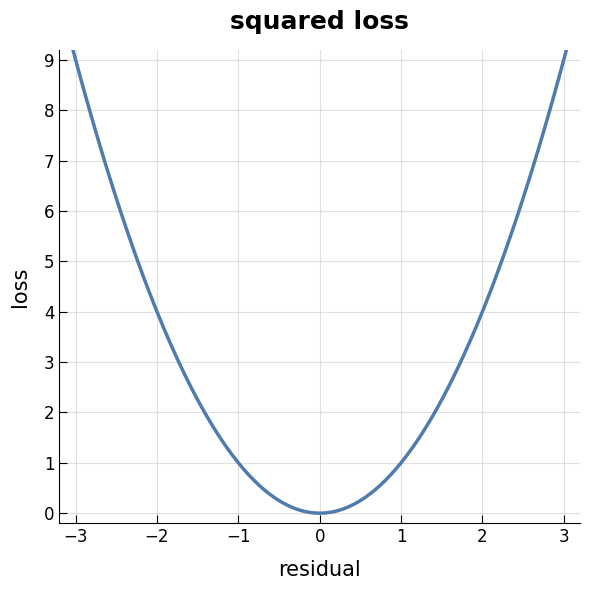

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 생성
residuals = np.linspace(-3.2, 3.2, 100)
loss = residuals ** 2  # y = x^2 함수

# 2. 그래프 설정 및 그리기
fig, ax = plt.subplots(figsize=(6, 6))

# Squared loss 곡선을 그립니다.
ax.plot(residuals, loss, color='#4F7CAC', linewidth=2.5)

# 3. 제목 및 축 레이블 설정
ax.set_title("squared loss", fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel("residual", fontsize=15, labelpad=10)
ax.set_ylabel("loss", fontsize=15, labelpad=10)

# 4. 축 범위 및 눈금(tick) 설정
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-0.2, 9.2)

ax.set_xticks(range(-3, 4))
ax.set_yticks(range(0, 10))

# 5. 그리드 및 스파인(spines) 설정
ax.grid(True, linestyle='-', color='lightgray', alpha=0.7)

ax.tick_params(direction='in', length=6, colors='black', labelsize=12)

ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 6. 그래프 전체 레이아웃 및 출력
plt.tight_layout() # 레이아웃 최적화
plt.show() # 그래프 표시

### Zero-One Loss Function

In [15]:
def binary_classifier(params: Parameters, x: np.ndarray) -> float:
  """Applies the linear predictor given by `params` to input `x`."""
  logit = params.weight @ x + params.bias
  if logit > 0:
      predicted_y = 1
  else:
      predicted_y = -1
  return predicted_y

def zero_one_loss(example: Example, params: Parameters) -> float:
  predicted_y = binary_classifier(params, example.x)
  loss = int(predicted_y != example.target_y)  # 조건문으로 표현
  return loss

loss = zero_one_loss(Example(x=np.array([2, 0]), target_y=1), params)
loss = zero_one_loss(Example(x=np.array([0, -2]), target_y=-1), params)

### Zero-One Loss Inline

In [18]:
def zero_one_loss_inline(example: Example, params: Parameters) -> float:
  # logit: sign is prediction, magnitude is how confident we are
  logit = example.x @ params.weight + params.bias
  # margin: sign measures correct (+) or not (-)
  margin = logit * example.target_y
  loss = int(margin <= 0)  # Whether the prediction was wrong
  return loss

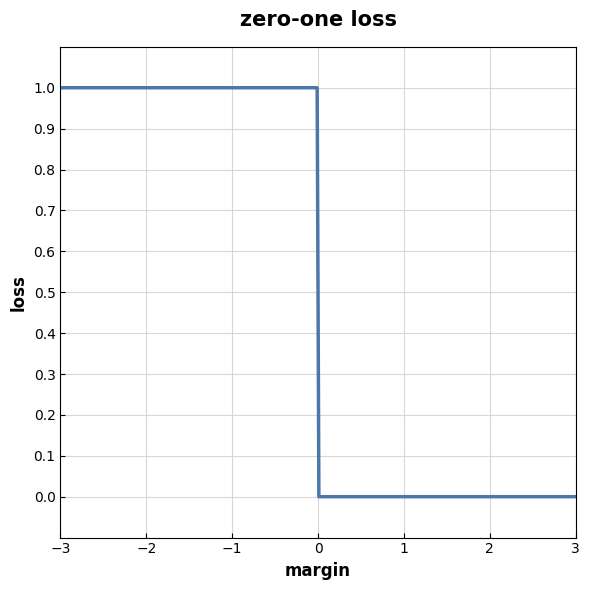

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 생성
margin = np.linspace(-3, 3, 300)

# zero-one loss 함수: margin이 0 이하면 1, 0 초과면 0
loss = np.where(margin <= 0, 1.0, 0.0)

# 2. 그래프 설정 및 그리기
fig, ax = plt.subplots(figsize=(6, 6))

# Zero-one loss 선 그리기
ax.plot(margin, loss, color='#4c78a8', linewidth=2.5)

# 3. 제목 및 축 레이블 설정
ax.set_title("zero-one loss", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("margin", fontsize=12, fontweight='bold')
ax.set_ylabel("loss", fontsize=12, fontweight='bold')

# 4. 축 범위 및 눈금 설정
ax.set_xlim(-3, 3)
ax.set_ylim(-0.1, 1.1)

# x축은 -3부터 3까지 정수, y축은 0.0부터 1.0까지 0.1 단위로 설정
ax.set_xticks(np.arange(-3, 4, 1))
ax.set_yticks(np.arange(0, 1.1, 0.1))

# 5. 그리드 및 스파인(테두리) 설정
ax.grid(True, linestyle='-', color='lightgray', alpha=0.9, zorder=0)

# 축 눈금 스타일 (안쪽으로 향하게)
ax.tick_params(direction='in', colors='black')

# 6. 출력
plt.tight_layout()
plt.show()

### Logistic Function